# AAUM Model Training — Train 7 ML/DL Models on 415K Historical Predictions

Train **XGBoost, LightGBM, RandomForest, CatBoost, LSTM, 1D-CNN, Transformer** on 10 years of NSE data (96 stocks, ~415K predictions).

**Pipeline:**
1. Load historical OHLCV + backtest predictions from Google Drive
2. Engineer 25+ technical features per prediction
3. Time-based train/test split (2015-2022 train, 2023-2025 test)
4. Train 4 classical ML models with early stopping
5. Train 3 deep learning models on GPU
6. Compare all 7 models, analyze per-stock performance
7. Export trained models to Google Drive for deployment

**Runtime:** ~2-3 hours on Colab T4 GPU

In [2]:
# =============================================================================
# Cell 1: Setup, Mount Drive, Load Data
# =============================================================================
import gc
import warnings
warnings.filterwarnings('ignore')

import os, sys, time, zipfile, glob, json
import subprocess

# --- Install dependencies ---
print('Installing dependencies...')
subprocess.run(
    ['pip', 'install', '-q', 'xgboost', 'lightgbm', 'catboost',
     'scikit-learn', 'ta', 'tqdm', 'torch', 'numpy', 'pandas',
     'matplotlib', 'seaborn'],
    capture_output=True
)
print('Dependencies installed.')

# --- Mount Google Drive (with retry logic) ---
from google.colab import drive

MOUNT_POINT = '/content/drive'
MAX_MOUNT_RETRIES = 3
MOUNT_RETRY_DELAY = 5

for attempt in range(1, MAX_MOUNT_RETRIES + 1):
    try:
        drive.mount(MOUNT_POINT, force_remount=True)
        print(f'Drive mounted successfully on attempt {attempt}.')
        break
    except Exception as mount_err:
        print(f'Mount attempt {attempt}/{MAX_MOUNT_RETRIES} failed: {mount_err}')
        if attempt < MAX_MOUNT_RETRIES:
            print(f'Retrying in {MOUNT_RETRY_DELAY}s...')
            time.sleep(MOUNT_RETRY_DELAY)
        else:
            print('ERROR: All mount attempts failed.')
            print('Try: Runtime -> Disconnect and reconnect, then re-run.')
            raise RuntimeError('Google Drive mount failed after all retries') from mount_err

DRIVE_ROOT = '/content/drive/MyDrive'
HSTRY_DIR = '/content/HSTRY'
RESULTS_DIR = os.path.join(DRIVE_ROOT, 'aaum_backtest_results')
MODELS_DIR = os.path.join(DRIVE_ROOT, 'aaum_trained_models')
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Find and unzip HSTRY ---
if os.path.isdir(os.path.join(DRIVE_ROOT, 'HSTRY')):
    HSTRY_DIR = os.path.join(DRIVE_ROOT, 'HSTRY')
    print('Found HSTRY folder on Drive')
elif os.path.isdir(os.path.join(DRIVE_ROOT, 'HSTRY_1h')):
    HSTRY_DIR = os.path.join(DRIVE_ROOT, 'HSTRY_1h')
    print('Found HSTRY_1h folder on Drive')
else:
    zip_candidates = (
        glob.glob(os.path.join(DRIVE_ROOT, '*HSTRY*.zip'))
        + glob.glob(os.path.join(DRIVE_ROOT, '*hstry*.zip'))
        + glob.glob(os.path.join(DRIVE_ROOT, '*1h*.zip'))
    )
    if zip_candidates:
        zf = zip_candidates[0]
        print(f'Found zip: {os.path.basename(zf)} -- extracting...')
        os.makedirs('/content/HSTRY', exist_ok=True)
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall('/content/HSTRY')
        subdirs = [d for d in os.listdir('/content/HSTRY')
                   if os.path.isdir(os.path.join('/content/HSTRY', d))]
        if subdirs and not glob.glob('/content/HSTRY/*.csv'):
            HSTRY_DIR = os.path.join('/content/HSTRY', subdirs[0])
        else:
            HSTRY_DIR = '/content/HSTRY'
        print(f'Extracted to {HSTRY_DIR}')
    else:
        print('No HSTRY folder or zip found on Drive!')
        print('Please upload HSTRY_1h.zip to MyDrive.')

# --- Find CSV files ---
hourly_csvs = sorted(
    glob.glob(os.path.join(HSTRY_DIR, '*_1h.csv'))
    + glob.glob(os.path.join(HSTRY_DIR, '**/*_1h.csv'), recursive=True)
)
if not hourly_csvs:
    hourly_csvs = sorted(glob.glob(os.path.join(HSTRY_DIR, '*.csv')))

print(f'CSV files found: {len(hourly_csvs)}')

# --- Load all 1h CSVs into daily OHLCV ---
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

print('Loading and resampling hourly CSVs to daily...')
csv_data = {}
load_errors = []

for csv_file_path in tqdm(hourly_csvs, desc='Loading CSVs'):
    try:
        fname = os.path.basename(csv_file_path)
        if '_NSE_' in fname:
            symbol = fname.rsplit('_NSE_', 1)[0]
        else:
            symbol = fname.replace('.csv', '')

        df = pd.read_csv(csv_file_path)
        df.columns = [c.lower().strip() for c in df.columns]

        if 'date' in df.columns and 'time' in df.columns:
            df['datetime'] = pd.to_datetime(
                df['date'].astype(str) + ' ' + df['time'].astype(str),
                format='mixed', dayfirst=False
            )
        elif 'date' in df.columns:
            df['datetime'] = pd.to_datetime(df['date'], format='mixed')
        else:
            load_errors.append(f'{fname}: no date column')
            continue

        required = ['open', 'high', 'low', 'close', 'volume']
        missing = [c for c in required if c not in df.columns]
        if missing:
            load_errors.append(f'{fname}: missing {missing}')
            continue

        df = df.set_index('datetime').sort_index()
        daily = df.resample('1D').agg({
            'open': 'first', 'high': 'max', 'low': 'min',
            'close': 'last', 'volume': 'sum'
        }).dropna(subset=['close'])
        daily = daily.reset_index()
        daily = daily.rename(columns={'datetime': 'date'})
        daily['date'] = daily['date'].dt.strftime('%Y-%m-%d')
        csv_data[symbol] = daily
    except Exception as e:
        load_errors.append(f'{os.path.basename(csv_file_path)}: {e}')

print(f'Loaded {len(csv_data)} symbols')
if load_errors:
    print(f'Errors: {len(load_errors)} (first 3: {load_errors[:3]})')

# --- Load predictions ---
pred_path = os.path.join(RESULTS_DIR, 'all_predictions.csv')
if not os.path.exists(pred_path):
    print(f'ERROR: {pred_path} not found!')
    print('Run the backtest notebook first to generate predictions.')
else:
    predictions_df = pd.read_csv(pred_path)
    print(f'Predictions loaded: {len(predictions_df):,} rows')
    print(f'Columns: {list(predictions_df.columns)}')
    print(f'Agents: {predictions_df["agent"].nunique()}')
    print(f'Symbols: {predictions_df["symbol"].nunique()}')
    print(f'Date range: {predictions_df["date"].min()} to {predictions_df["date"].max()}')
    print()
    print(predictions_df.head(3))


Installing dependencies...
Dependencies installed.
Mounted at /content/drive
Drive mounted successfully on attempt 1.
Found zip: HSTRY_1h.zip -- extracting...
Extracted to /content/HSTRY
CSV files found: 192
Loading and resampling hourly CSVs to daily...


Loading CSVs:   0%|          | 0/192 [00:00<?, ?it/s]

Loaded 96 symbols
Predictions loaded: 415,287 rows
Columns: ['agent', 'symbol', 'date', 'rec', 'actual', 'confidence', 'price_change', 'regime', 'correct']
Agents: 9
Symbols: 96
Date range: 2015-06-01 to 2025-05-22

      agent              symbol        date   rec actual  confidence  \
0    Rakesh  /content/HSTRY/ABB  2015-06-01  HOLD   DOWN         0.3   
1    Graham  /content/HSTRY/ABB  2015-06-01  HOLD   DOWN         0.3   
2  Momentum  /content/HSTRY/ABB  2015-06-01  HOLD   DOWN         0.3   

   price_change   regime  correct  
0       -4.2422  Unknown    False  
1       -4.2422  Unknown    False  
2       -4.2422  Unknown    False  


In [3]:
# =============================================================================
# Cell 2: Feature Engineering -- 25+ Technical Features per Prediction
# =============================================================================
import warnings
warnings.filterwarnings('ignore')
from datetime import date, datetime, timedelta
from typing import Optional

# --- CSVHistoricalDataProvider (same as backtest notebook) ---
class CSVHistoricalDataProvider:
    def __init__(self, data):
        self._data = data
        self._symbols = sorted(data.keys())

    def get_price_history(self, symbol, start, end):
        symbol = symbol.replace('.NS', '').replace('.BO', '')
        if symbol not in self._data:
            return pd.DataFrame()
        df = self._data[symbol].copy()
        start_str, end_str = str(start), str(end)
        return df[(df['date'] >= start_str) & (df['date'] <= end_str)]

    def compute_technicals(self, symbol, as_of_date):
        """Compute 25+ technical features as of a given date."""
        if isinstance(as_of_date, str):
            as_of_date = date.fromisoformat(as_of_date)
        start = as_of_date - timedelta(days=400)
        df = self.get_price_history(symbol, start, as_of_date)
        if df.empty or len(df) < 30:
            return {}
        df = df.copy()
        df['_date'] = pd.to_datetime(df['date']).dt.date
        df = df[df['_date'] <= as_of_date].sort_values('_date')
        if len(df) < 30:
            return {}

        close = df['close'].astype(float)
        high = df['high'].astype(float)
        low = df['low'].astype(float)
        volume = df['volume'].astype(float)
        technicals = {}

        # --- RSI ---
        try:
            from ta.momentum import RSIIndicator
            rsi_s = RSIIndicator(close, window=14).rsi()
            technicals['rsi_14'] = round(float(rsi_s.iloc[-1]), 2) if not rsi_s.empty else 50.0
        except Exception:
            technicals['rsi_14'] = 50.0

        # --- MACD ---
        try:
            from ta.trend import MACD
            macd_ind = MACD(close)
            macd_line = macd_ind.macd()
            signal_line = macd_ind.macd_signal()
            hist = macd_ind.macd_diff()
            technicals['macd'] = round(float(macd_line.iloc[-1]), 4)
            technicals['macd_signal'] = round(float(signal_line.iloc[-1]), 4)
            technicals['macd_histogram'] = round(float(hist.iloc[-1]), 4)
        except Exception:
            technicals['macd'] = 0.0
            technicals['macd_signal'] = 0.0
            technicals['macd_histogram'] = 0.0

        # --- Bollinger Bands ---
        try:
            from ta.volatility import BollingerBands
            bb = BollingerBands(close, window=20)
            bb_upper = float(bb.bollinger_hband().iloc[-1])
            bb_lower = float(bb.bollinger_lband().iloc[-1])
            current_price = float(close.iloc[-1])
            technicals['bb_upper'] = round(bb_upper, 2)
            technicals['bb_lower'] = round(bb_lower, 2)
            bb_range = bb_upper - bb_lower
            technicals['bb_pct'] = round((current_price - bb_lower) / bb_range, 4) if bb_range > 0 else 0.5
        except Exception:
            technicals['bb_upper'] = 0.0
            technicals['bb_lower'] = 0.0
            technicals['bb_pct'] = 0.5

        # --- EMAs ---
        try:
            from ta.trend import EMAIndicator
            technicals['ema_9'] = round(float(EMAIndicator(close, window=9).ema_indicator().iloc[-1]), 2)
            technicals['ema_21'] = round(float(EMAIndicator(close, window=21).ema_indicator().iloc[-1]), 2)
            if len(close) >= 50:
                technicals['ema_50'] = round(float(EMAIndicator(close, window=50).ema_indicator().iloc[-1]), 2)
            else:
                technicals['ema_50'] = technicals['ema_21']
            if len(close) >= 200:
                ema200 = float(EMAIndicator(close, window=200).ema_indicator().iloc[-1])
                technicals['ema_200'] = round(ema200, 2)
                technicals['price_above_200dma'] = 1.0 if float(close.iloc[-1]) > ema200 else 0.0
            else:
                technicals['ema_200'] = technicals['ema_50']
                technicals['price_above_200dma'] = 0.5
        except Exception:
            technicals['ema_9'] = 0.0
            technicals['ema_21'] = 0.0
            technicals['ema_50'] = 0.0
            technicals['ema_200'] = 0.0
            technicals['price_above_200dma'] = 0.5

        # --- ATR ---
        try:
            from ta.volatility import AverageTrueRange
            atr = AverageTrueRange(high, low, close, window=14).average_true_range()
            technicals['atr_14'] = round(float(atr.iloc[-1]), 4)
            cp = float(close.iloc[-1])
            technicals['atr_pct'] = round(technicals['atr_14'] / cp * 100, 4) if cp > 0 else 0.0
        except Exception:
            technicals['atr_14'] = 0.0
            technicals['atr_pct'] = 0.0

        # --- Volume ---
        try:
            avg_vol = float(volume.iloc[-20:].mean()) if len(volume) >= 20 else float(volume.mean())
            current_vol = float(volume.iloc[-1])
            technicals['volume_ratio'] = round(current_vol / avg_vol, 2) if avg_vol > 0 else 1.0
            technicals['volume_surge'] = 1.0 if technicals['volume_ratio'] > 2.0 else 0.0
        except Exception:
            technicals['volume_ratio'] = 1.0
            technicals['volume_surge'] = 0.0

        # --- Sharpe & Alpha (guarded against div-by-zero and inf) ---
        try:
            returns = close.pct_change().dropna()
            if len(returns) >= 90:
                wr = returns.iloc[-90:]
                mean_ret = float(wr.mean())
                std_ret = float(wr.std())
                if std_ret > 1e-10:
                    sharpe_val = (mean_ret / std_ret) * (252 ** 0.5)
                    technicals['sharpe_90d'] = round(float(np.clip(sharpe_val, -100, 100)), 4)
                else:
                    technicals['sharpe_90d'] = 0.0
                cumulative_ret = float((1 + wr).prod() - 1)
                alpha_val = cumulative_ret * 100
                technicals['alpha_90d'] = round(float(np.clip(alpha_val, -1e6, 1e6)), 4)
            else:
                technicals['sharpe_90d'] = 0.0
                technicals['alpha_90d'] = 0.0
        except Exception:
            technicals['sharpe_90d'] = 0.0
            technicals['alpha_90d'] = 0.0

        # --- ADX ---
        try:
            from ta.trend import ADXIndicator
            adx = ADXIndicator(high, low, close, window=14)
            technicals['adx_14'] = round(float(adx.adx().iloc[-1]), 2)
        except Exception:
            technicals['adx_14'] = 25.0

        # --- Lookback returns ---
        try:
            cp = float(close.iloc[-1])
            if len(close) >= 2 and float(close.iloc[-2]) > 0:
                technicals['return_1d'] = round((cp / float(close.iloc[-2]) - 1) * 100, 4)
            else:
                technicals['return_1d'] = 0.0
            if len(close) >= 4 and float(close.iloc[-4]) > 0:
                technicals['return_3d'] = round((cp / float(close.iloc[-4]) - 1) * 100, 4)
            else:
                technicals['return_3d'] = 0.0
            if len(close) >= 6 and float(close.iloc[-6]) > 0:
                technicals['return_5d'] = round((cp / float(close.iloc[-6]) - 1) * 100, 4)
            else:
                technicals['return_5d'] = 0.0
        except Exception:
            technicals['return_1d'] = 0.0
            technicals['return_3d'] = 0.0
            technicals['return_5d'] = 0.0

        # --- Price position: distance from 52-week high/low ---
        try:
            cp = float(close.iloc[-1])
            if len(close) >= 252:
                h52 = float(high.iloc[-252:].max())
                l52 = float(low.iloc[-252:].min())
            else:
                h52 = float(high.max())
                l52 = float(low.min())
            rng = h52 - l52
            technicals['dist_52w_high'] = round((h52 - cp) / cp * 100, 4) if cp > 0 else 0.0
            technicals['dist_52w_low'] = round((cp - l52) / cp * 100, 4) if cp > 0 else 0.0
            technicals['price_position_52w'] = round((cp - l52) / rng, 4) if rng > 0 else 0.5
        except Exception:
            technicals['dist_52w_high'] = 0.0
            technicals['dist_52w_low'] = 0.0
            technicals['price_position_52w'] = 0.5

        technicals['current_price'] = round(float(close.iloc[-1]), 2)

        # --- Final safety: replace any inf/NaN in technicals dict ---
        for k, v in technicals.items():
            if isinstance(v, float) and (np.isinf(v) or np.isnan(v)):
                technicals[k] = 0.0

        return technicals


csv_provider = CSVHistoricalDataProvider(csv_data)
print(f'CSVHistoricalDataProvider ready: {len(csv_provider._symbols)} symbols')

# --- Build feature matrix ---
print()
print('Building feature matrix from predictions...')
print('This computes 25+ technical indicators for each (symbol, date) pair.')
print('Estimated time: 15-30 min for 415K predictions.')
print()

# Deduplicate: unique (symbol, date) pairs
unique_pairs = predictions_df.drop_duplicates(subset=['symbol', 'date'])[['symbol', 'date', 'actual', 'price_change', 'regime']].copy()
print(f'Unique (symbol, date) pairs: {len(unique_pairs):,}')

FEATURE_COLS = [
    'rsi_14', 'macd', 'macd_signal', 'macd_histogram',
    'bb_upper', 'bb_lower', 'bb_pct',
    'ema_9', 'ema_21', 'ema_50', 'ema_200', 'price_above_200dma',
    'atr_14', 'atr_pct', 'volume_ratio', 'volume_surge',
    'sharpe_90d', 'alpha_90d', 'adx_14',
    'return_1d', 'return_3d', 'return_5d',
    'dist_52w_high', 'dist_52w_low', 'price_position_52w',
]

feature_rows = []
skipped = 0
empty_technicals = 0
t0 = time.time()

# --- Normalize symbols: strip paths, keep just stock name ---
def normalize_symbol(s):
    """Extract clean symbol from any format."""
    s = str(s).upper().strip()
    # Remove file extensions
    s = s.replace('.CSV', '').replace('.NS', '').replace('.BO', '')
    # Remove path prefix
    s = os.path.basename(s)
    # Remove _NSE_ suffix and timeframe
    if '_NSE_' in s:
        s = s.split('_NSE_')[0]
    elif '_1H' in s:
        s = s.split('_1H')[0]
    elif '_15M' in s:
        s = s.split('_15M')[0]
    return s.strip()

# Normalize prediction symbols
unique_pairs['symbol_clean'] = unique_pairs['symbol'].apply(normalize_symbol)
predictions_df['symbol_clean'] = predictions_df['symbol'].apply(normalize_symbol)

# Build lookup from csv_data keys (normalize csv keys the same way)
csv_symbol_map = {}
for key in csv_data.keys():
    clean = normalize_symbol(key)
    csv_symbol_map[clean] = key
print(f'CSV symbol map: {len(csv_symbol_map)} symbols')
print(f'Prediction symbols (sample): {unique_pairs["symbol_clean"].unique()[:5].tolist()}')
print(f'CSV data keys (sample): {list(csv_symbol_map.keys())[:5]}')
overlap = set(unique_pairs['symbol_clean'].unique()) & set(csv_symbol_map.keys())
print(f'Overlapping symbols: {len(overlap)}')

if len(overlap) == 0:
    print()
    print('WARNING: Zero overlap between prediction symbols and CSV symbols!')
    print('Check symbol formats. Prediction symbols:')
    print(f'  {sorted(unique_pairs["symbol_clean"].unique())[:10]}')
    print('CSV symbols:')
    print(f'  {sorted(csv_symbol_map.keys())[:10]}')

for idx, row in tqdm(unique_pairs.iterrows(), total=len(unique_pairs), desc='Computing features'):
    symbol = row['symbol_clean']
    # Map to csv_data key
    csv_key = csv_symbol_map.get(symbol)
    if not csv_key:
        skipped += 1
        continue
    dt = row['date']
    techs = csv_provider.compute_technicals(csv_key, dt)
    if not techs:
        empty_technicals += 1
        skipped += 1
        continue

    feat = {'symbol': symbol, 'date': dt}
    for col in FEATURE_COLS:
        val = techs.get(col, np.nan)
        if isinstance(val, bool):
            val = 1.0 if val else 0.0
        # Safety: replace inf with NaN (will be filled later)
        if isinstance(val, float) and np.isinf(val):
            val = np.nan
        feat[col] = val

    # Confidence from prediction (average across agents for this symbol+date)
    conf_slice = predictions_df[
        (predictions_df['symbol_clean'] == symbol) & (predictions_df['date'] == dt)
    ]['confidence']
    feat['avg_confidence'] = float(conf_slice.mean()) if len(conf_slice) > 0 else 0.5

    # Label: actual direction
    actual = row['actual']
    if actual == 'UP':
        feat['label'] = 0
    elif actual == 'DOWN':
        feat['label'] = 1
    else:
        feat['label'] = 2  # FLAT

    feat['price_change'] = row.get('price_change', 0.0)
    feat['regime'] = row.get('regime', 'unknown')
    feature_rows.append(feat)

elapsed = time.time() - t0
print(f'Feature computation done in {elapsed/60:.1f} min')
print(f'Rows with features: {len(feature_rows):,}')
print(f'Skipped (no CSV match): {skipped - empty_technicals:,}')
print(f'Skipped (empty technicals / insufficient data): {empty_technicals:,}')

if len(feature_rows) == 0:
    raise RuntimeError('No feature rows produced! Check symbol matching between predictions and CSV data.')

features_df = pd.DataFrame(feature_rows)

# --- Cast to float32 to halve RAM usage ---
features_df[FEATURE_COLS] = features_df[FEATURE_COLS].astype(np.float32)

# --- Handle inf and NaN: replace inf -> NaN, fill NaN with median, clip extremes ---
for col in FEATURE_COLS:
    features_df[col] = features_df[col].replace([np.inf, -np.inf], np.nan)
    if features_df[col].isna().any():
        med = features_df[col].median()
        if pd.isna(med):
            med = 0.0
        features_df[col] = features_df[col].fillna(med)
    # Clip extreme values
    features_df[col] = features_df[col].clip(-1e6, 1e6)

nan_remaining = features_df[FEATURE_COLS].isna().sum().sum()
inf_remaining = np.isinf(features_df[FEATURE_COLS].values.astype(float)).sum()
print(f'After cleanup: NaN remaining={nan_remaining}, inf remaining={inf_remaining}')

# --- Save to Drive ---
features_path = os.path.join(MODELS_DIR, 'features.csv')
features_df.to_csv(features_path, index=False)
size_mb = os.path.getsize(features_path) / (1024 * 1024)
print(f'Saved features to {features_path} ({size_mb:.1f} MB)')

# --- Statistics ---
print()
print('=== Feature Statistics ===')
print(features_df[FEATURE_COLS].describe().round(3).to_string())
print()
print('=== Class Distribution ===')
label_map = {0: 'UP', 1: 'DOWN', 2: 'FLAT'}
for lbl in sorted(features_df['label'].unique()):
    cnt = (features_df['label'] == lbl).sum()
    pct = cnt / len(features_df) * 100
    print(f'  {label_map.get(lbl, lbl)}: {cnt:,} ({pct:.1f}%)')

gc.collect()
print(f'Memory freed after feature computation')


CSVHistoricalDataProvider ready: 96 symbols

Building feature matrix from predictions...
This computes 25+ technical indicators for each (symbol, date) pair.
Estimated time: 15-30 min for 415K predictions.

Unique (symbol, date) pairs: 46,143
CSV symbol map: 96 symbols
Prediction symbols (sample): ['ABB', 'ADANIENSOL', 'ADANIENT', 'ADANIPORTS', 'AMBUJACEM']
CSV data keys (sample): ['ABB', 'ADANIENSOL', 'ADANIENT', 'ADANIPORTS', 'AMBUJACEM']
Overlapping symbols: 96


Computing features:   0%|          | 0/46143 [00:00<?, ?it/s]

Feature computation done in 65.4 min
Rows with features: 46,143
Skipped (no CSV match): 0
Skipped (empty technicals / insufficient data): 0
After cleanup: NaN remaining=0, inf remaining=0
Saved features to /content/drive/MyDrive/aaum_trained_models/features.csv (10.0 MB)

=== Feature Statistics ===
          rsi_14       macd  macd_signal  macd_histogram   bb_upper   bb_lower     bb_pct      ema_9     ema_21     ema_50    ema_200  price_above_200dma     atr_14    atr_pct  volume_ratio  volume_surge  sharpe_90d    alpha_90d     adx_14  return_1d  return_3d  return_5d  dist_52w_high  dist_52w_low  price_position_52w
count  46143.000  46143.000    46143.000       46143.000  46143.000  46143.000  46143.000  46143.000  46143.000  46143.000  46143.000           46143.000  46143.000  46143.000     46143.000     46143.000   46143.000    46143.000  46143.000  46143.000  46143.000  46143.000      46143.000     46143.000           46143.000
mean      52.307      5.331        5.217           0.116

In [4]:
# =============================================================================
# Cell 3: Time-Based Train/Test Split
# =============================================================================
from sklearn.preprocessing import StandardScaler
import joblib

# --- Load features if resuming ---
if 'features_df' not in dir() or features_df is None:
    features_path = os.path.join(MODELS_DIR, 'features.csv')
    if not os.path.exists(features_path):
        raise FileNotFoundError(f'features.csv not found at {features_path}. Run Cell 2 first.')
    features_df = pd.read_csv(features_path)
    print(f'Loaded features from disk: {len(features_df):,} rows')

# --- Guard: ensure FEATURE_COLS is defined ---
if 'FEATURE_COLS' not in dir():
    FEATURE_COLS = [
        'rsi_14', 'macd', 'macd_signal', 'macd_histogram',
        'bb_upper', 'bb_lower', 'bb_pct',
        'ema_9', 'ema_21', 'ema_50', 'ema_200', 'price_above_200dma',
        'atr_14', 'atr_pct', 'volume_ratio', 'volume_surge',
        'sharpe_90d', 'alpha_90d', 'adx_14',
        'return_1d', 'return_3d', 'return_5d',
        'dist_52w_high', 'dist_52w_low', 'price_position_52w',
    ]

# --- Time-based split: NO random split (prevents data leakage) ---
TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'

train_mask = features_df['date'] <= TRAIN_END
test_mask = features_df['date'] >= TEST_START

train_df = features_df[train_mask].copy()
test_df = features_df[test_mask].copy()

if len(train_df) == 0:
    raise RuntimeError(f'Train set is empty! No data before {TRAIN_END}.')
if len(test_df) == 0:
    raise RuntimeError(f'Test set is empty! No data after {TEST_START}.')

print(f'Train set: {len(train_df):,} rows ({train_df["date"].min()} to {train_df["date"].max()})')
print(f'Test set:  {len(test_df):,} rows ({test_df["date"].min()} to {test_df["date"].max()})')
print(f'Split ratio: {len(train_df)/len(features_df)*100:.1f}% train / {len(test_df)/len(features_df)*100:.1f}% test')

# --- Class distribution in each split ---
print()
label_map = {0: 'UP', 1: 'DOWN', 2: 'FLAT'}
for name, subset in [('Train', train_df), ('Test', test_df)]:
    print(f'{name} class distribution:')
    for lbl in sorted(subset['label'].unique()):
        cnt = (subset['label'] == lbl).sum()
        pct = cnt / len(subset) * 100
        print(f'  {label_map.get(lbl, lbl)}: {cnt:,} ({pct:.1f}%)')

# FEATURE_COLS_PLUS: features + avg_confidence
FEATURE_COLS_PLUS = FEATURE_COLS + ['avg_confidence']

# Verify all feature columns exist in dataframe
missing_cols = [c for c in FEATURE_COLS_PLUS if c not in features_df.columns]
if missing_cols:
    print(f'WARNING: Missing columns in features_df: {missing_cols}')
    print('Removing missing columns from FEATURE_COLS_PLUS')
    FEATURE_COLS_PLUS = [c for c in FEATURE_COLS_PLUS if c in features_df.columns]

X_train = train_df[FEATURE_COLS_PLUS].values.astype(np.float64)
y_train = train_df['label'].values.astype(np.int64)
X_test = test_df[FEATURE_COLS_PLUS].values.astype(np.float64)
y_test = test_df['label'].values.astype(np.int64)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

# --- Clean inf/extreme values BEFORE scaling ---
import numpy as np
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_test = np.where(np.isinf(X_test), np.nan, X_test)

# Fill NaN with column median from train
from numpy import nanmedian
col_medians = nanmedian(X_train, axis=0)
# If a column is entirely NaN, median will be NaN; replace with 0
col_medians = np.where(np.isnan(col_medians), 0.0, col_medians)
for c in range(X_train.shape[1]):
    mask_tr = np.isnan(X_train[:, c])
    X_train[mask_tr, c] = col_medians[c]
    mask_te = np.isnan(X_test[:, c])
    X_test[mask_te, c] = col_medians[c]

# Clip extreme values to prevent overflow
X_train = np.clip(X_train, -1e6, 1e6)
X_test = np.clip(X_test, -1e6, 1e6)

# Final verification
inf_count = np.isinf(X_train).sum() + np.isinf(X_test).sum()
nan_count = np.isnan(X_train).sum() + np.isnan(X_test).sum()
print(f'After cleaning: inf={inf_count}, nan={nan_count}')
if inf_count > 0 or nan_count > 0:
    raise RuntimeError('Data still contains inf or NaN after cleaning! Cannot proceed with scaling.')

# Cast back to float32 for efficiency
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path}')

# Save feature column names
feat_cols_path = os.path.join(MODELS_DIR, 'feature_columns.json')
with open(feat_cols_path, 'w') as f:
    json.dump(FEATURE_COLS_PLUS, f)
print(f'Feature columns saved to {feat_cols_path}')

# --- Compute class weights for imbalanced data ---
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), class_weights.tolist()))
print(f'Class weights: {class_weight_dict}')

# Store metadata
split_info = {
    'train_end': TRAIN_END,
    'test_start': TEST_START,
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'n_features': len(FEATURE_COLS_PLUS),
    'feature_columns': FEATURE_COLS_PLUS,
    'class_weights': {int(k): float(v) for k, v in class_weight_dict.items()},
}
print()
print('Ready for training.')


Train set: 34,724 rows (2015-06-01 to 2022-12-30)
Test set:  11,419 rows (2023-01-02 to 2025-05-22)
Split ratio: 75.3% train / 24.7% test

Train class distribution:
  UP: 16,398 (47.2%)
  DOWN: 14,504 (41.8%)
  FLAT: 3,822 (11.0%)
Test class distribution:
  UP: 5,606 (49.1%)
  DOWN: 4,423 (38.7%)
  FLAT: 1,390 (12.2%)
X_train shape: (34724, 26)
X_test shape:  (11419, 26)
After cleaning: inf=0, nan=0
Scaler saved to /content/drive/MyDrive/aaum_trained_models/scaler.joblib
Feature columns saved to /content/drive/MyDrive/aaum_trained_models/feature_columns.json
Class weights: {0: 0.7058584380208969, 1: 0.7980327266041551, 2: 3.0284318855747427}

Ready for training.


In [5]:
# =============================================================================
# Cell 4: Train 4 Classical ML Models
# =============================================================================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, brier_score_loss, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib

# --- Guard: ensure required variables from Cell 3 ---
if 'FEATURE_COLS_PLUS' not in dir():
    feat_cols_path = os.path.join(MODELS_DIR, 'feature_columns.json')
    if os.path.exists(feat_cols_path):
        with open(feat_cols_path, 'r') as f:
            FEATURE_COLS_PLUS = json.load(f)
        print(f'Loaded FEATURE_COLS_PLUS from disk: {len(FEATURE_COLS_PLUS)} features')
    else:
        raise RuntimeError('FEATURE_COLS_PLUS not defined and not found on disk. Run Cell 2 and 3 first.')

if 'class_weight_dict' not in dir():
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes.tolist(), class_weights.tolist()))
    print(f'Recomputed class_weight_dict: {class_weight_dict}')

ml_results = {}  # model_name -> {accuracy, f1, precision, recall, brier, time, model, y_pred, y_proba}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fit_params=None):
    """Train and evaluate a single model. Returns metrics dict."""
    print(f'Training {name}...')
    t0 = time.time()
    if fit_params:
        model.fit(X_tr, y_tr, **fit_params)
    else:
        model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    # Brier score (multi-class: average per-class one-vs-rest)
    n_classes = y_proba.shape[1]
    brier = 0.0
    for c in range(n_classes):
        y_bin = (y_te == c).astype(float)
        brier += brier_score_loss(y_bin, y_proba[:, c])
    brier /= n_classes

    print(f'  {name}: acc={acc:.4f}, F1={f1:.4f}, prec={prec:.4f}, rec={rec:.4f}, brier={brier:.4f}, time={train_time:.1f}s')

    return {
        'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
        'brier': brier, 'train_time': train_time,
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
    }


# --- Compute sample weights safely (handle labels not in class_weight_dict) ---
default_weight = np.mean(list(class_weight_dict.values())) if class_weight_dict else 1.0
sample_weights_train = np.array([class_weight_dict.get(int(y), default_weight) for y in y_train])

# ===================== XGBoost =====================
try:
    xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        eval_metric='mlogloss',
        early_stopping_rounds=50,
        use_label_encoder=False,
        verbosity=0,
        tree_method='hist',
        n_jobs=-1,
    )
    ml_results['XGBoost'] = evaluate_model(
        'XGBoost', xgb_model, X_train_scaled, y_train, X_test_scaled, y_test,
        fit_params={'eval_set': [(X_test_scaled, y_test)], 'verbose': False,
                    'sample_weight': sample_weights_train}
    )
except Exception as e:
    print(f'ERROR training XGBoost: {e}')

# ===================== LightGBM =====================
try:
    lgbm_model = LGBMClassifier(
        n_estimators=500,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        verbose=-1,
        n_jobs=-1,
        class_weight='balanced',
    )
    ml_results['LightGBM'] = evaluate_model(
        'LightGBM', lgbm_model, X_train_scaled, y_train, X_test_scaled, y_test,
    )
except Exception as e:
    print(f'ERROR training LightGBM: {e}')

# ===================== RandomForest =====================
try:
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
    )
    ml_results['RandomForest'] = evaluate_model(
        'RandomForest', rf_model, X_train_scaled, y_train, X_test_scaled, y_test,
    )
except Exception as e:
    print(f'ERROR training RandomForest: {e}')

# ===================== CatBoost =====================
try:
    cb_model = CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.05,
        l2_leaf_reg=3,
        verbose=0,
        auto_class_weights='Balanced',
        eval_metric='MultiClass',
        early_stopping_rounds=50,
    )
    ml_results['CatBoost'] = evaluate_model(
        'CatBoost', cb_model, X_train_scaled, y_train, X_test_scaled, y_test,
        fit_params={'eval_set': (X_test_scaled, y_test), 'verbose': False}
    )
except Exception as e:
    print(f'ERROR training CatBoost: {e}')

# --- Save all successfully trained ML models ---
print()
if len(ml_results) == 0:
    print('WARNING: No ML models trained successfully!')
else:
    print(f'Saving {len(ml_results)} ML models to Google Drive...')
    if 'XGBoost' in ml_results:
        joblib.dump(ml_results['XGBoost']['model'], os.path.join(MODELS_DIR, 'xgboost_model.joblib'))
        print('  Saved xgboost_model.joblib')
    if 'LightGBM' in ml_results:
        joblib.dump(ml_results['LightGBM']['model'], os.path.join(MODELS_DIR, 'lightgbm_model.joblib'))
        print('  Saved lightgbm_model.joblib')
    if 'RandomForest' in ml_results:
        joblib.dump(ml_results['RandomForest']['model'], os.path.join(MODELS_DIR, 'randomforest_model.joblib'))
        print('  Saved randomforest_model.joblib')
    if 'CatBoost' in ml_results:
        ml_results['CatBoost']['model'].save_model(os.path.join(MODELS_DIR, 'catboost_model.cbm'))
        print('  Saved catboost_model.cbm')

# --- Feature importance (XGBoost, if available) ---
if 'XGBoost' in ml_results:
    print()
    print('=== XGBoost Feature Importance (Top 20) ===')
    import matplotlib.pyplot as plt

    importances = ml_results['XGBoost']['model'].feature_importances_
    feat_imp = sorted(zip(FEATURE_COLS_PLUS, importances), key=lambda x: x[1], reverse=True)
    for rank, (feat_name, imp) in enumerate(feat_imp[:20], 1):
        bar = '#' * int(imp * 200)
        print(f'  {rank:2d}. {feat_name:<25s} {imp:.4f}  {bar}')

# --- Summary table ---
print()
print('=== ML Model Summary ===')
trained_ml = [n for n in ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost'] if n in ml_results]
if trained_ml:
    print(f'{"Model":<16s} {"Accuracy":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s} {"Brier":>7s} {"Time":>8s}')
    print('-' * 70)
    for name in trained_ml:
        r = ml_results[name]
        t_str = f'{r["train_time"]:.0f}s'
        print(f'{name:<16s} {r["accuracy"]:>8.1%} {r["f1"]:>7.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {r["brier"]:>7.4f} {t_str:>8s}')
else:
    print('No ML models were trained successfully.')

gc.collect()
print('Memory freed after ML training')


Training XGBoost...
  XGBoost: acc=0.2714, F1=0.2880, prec=0.4045, rec=0.2714, brier=0.2223, time=11.6s
Training LightGBM...
  LightGBM: acc=0.4062, F1=0.4129, prec=0.4216, rec=0.4062, brier=0.2160, time=14.0s
Training RandomForest...
  RandomForest: acc=0.3195, F1=0.3427, prec=0.4195, rec=0.3195, brier=0.2206, time=44.1s
Training CatBoost...
  CatBoost: acc=0.2533, F1=0.2625, prec=0.4268, rec=0.2533, brier=0.2271, time=10.4s

Saving 4 ML models to Google Drive...
  Saved xgboost_model.joblib
  Saved lightgbm_model.joblib
  Saved randomforest_model.joblib
  Saved catboost_model.cbm

=== XGBoost Feature Importance (Top 20) ===
   1. atr_pct                   0.0620  ############
   2. alpha_90d                 0.0442  ########
   3. ema_200                   0.0430  ########
   4. ema_50                    0.0424  ########
   5. price_above_200dma        0.0407  ########
   6. avg_confidence            0.0402  ########
   7. atr_14                    0.0397  #######
   8. sharpe_90d    

In [5]:
import os
MODELS_DIR = '/content/drive/MyDrive/aaum_trained_models'
if os.path.isdir(MODELS_DIR):
    print('Files in MODELS_DIR:')
    for f in os.listdir(MODELS_DIR):
        size = os.path.getsize(os.path.join(MODELS_DIR, f))
        print(f'  {f} ({size/1024:.1f} KB)')
else:
    print(f'{MODELS_DIR} does not exist!')
    print('Run Cell 1 first to set up directories.')


/content/drive/MyDrive/aaum_trained_models does not exist!
Run Cell 1 first to set up directories.


In [6]:
# =============================================================================
# Cell 5: Train 3 Deep Learning Models (LSTM, 1D-CNN, Transformer)
# =============================================================================
# Re-mount Drive (it disconnects after long idle/compute)
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import brier_score_loss
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Memory: {gpu_mem:.1f} GB')

# =============================================================================
# Recover variables from earlier cells (or from saved files on Drive)
# =============================================================================
DRIVE_ROOT = '/content/drive/MyDrive'

if 'MODELS_DIR' not in globals():
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'aaum_trained_models')
    print(f'MODELS_DIR defaulted to {MODELS_DIR}')

if 'TRAIN_END' not in globals():
    TRAIN_END = '2022-12-31'
if 'TEST_START' not in globals():
    TEST_START = '2023-01-01'

print(f'MODELS_DIR : {MODELS_DIR}')
print(f'TRAIN_END  : {TRAIN_END}')
print(f'TEST_START : {TEST_START}')

# --- Load features_df ---
if 'features_df' not in globals() or features_df is None or len(features_df) == 0:
    features_path = os.path.join(MODELS_DIR, 'features.csv')
    if os.path.exists(features_path):
        features_df = pd.read_csv(features_path)
        print(f'Loaded features_df from disk: {len(features_df)} rows')
    else:
        raise RuntimeError(f'features.csv not found at {features_path}. Run Cell 2 first.')
print(f'features_df: {len(features_df)} rows, columns: {list(features_df.columns[:5])}...')

# --- Load FEATURE_COLS_PLUS ---
if 'FEATURE_COLS_PLUS' not in globals():
    feat_cols_path = os.path.join(MODELS_DIR, 'feature_columns.json')
    if os.path.exists(feat_cols_path):
        with open(feat_cols_path, 'r') as f:
            FEATURE_COLS_PLUS = json.load(f)
        print(f'Loaded FEATURE_COLS_PLUS: {len(FEATURE_COLS_PLUS)} features')
    else:
        raise RuntimeError('feature_columns.json not found. Run Cell 3 first.')
print(f'FEATURE_COLS_PLUS: {len(FEATURE_COLS_PLUS)} features')

# --- Verify all feature columns exist in features_df ---
missing_cols = [c for c in FEATURE_COLS_PLUS if c not in features_df.columns]
if missing_cols:
    print(f'WARNING: Missing columns: {missing_cols}')
    FEATURE_COLS_PLUS = [c for c in FEATURE_COLS_PLUS if c in features_df.columns]
    print(f'Reduced FEATURE_COLS_PLUS to {len(FEATURE_COLS_PLUS)} features')

# --- Load scaler ---
if 'scaler' not in globals():
    scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
    if os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        print('Loaded scaler from disk')
    else:
        raise RuntimeError(f'scaler.joblib not found at {scaler_path}. Run Cell 3 first.')

# --- Recover y_train ---
if 'y_train' not in globals():
    _train_df = features_df[features_df['date'] <= TRAIN_END]
    y_train = _train_df['label'].values.astype(np.int64)
    print(f'Recovered y_train: {len(y_train)} samples')
print(f'y_train unique labels: {np.unique(y_train).tolist()}')

# --- class_weight_dict (ensure Python int keys, not numpy int64) ---
if 'class_weight_dict' not in globals():
    from sklearn.utils.class_weight import compute_class_weight
    _classes = np.unique(y_train)
    _cw = compute_class_weight('balanced', classes=_classes, y=y_train)
    class_weight_dict = {int(k): float(v) for k, v in zip(_classes, _cw)}
    print(f'Computed class_weight_dict: {class_weight_dict}')
# FIX: force all keys to Python int (handles numpy int64 keys from earlier cells)
class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}
print(f'class_weight_dict: {class_weight_dict}')

# =============================================================================
# Prepare sequential data
# =============================================================================
WINDOW = 30
print(f'\nCreating sequences with window={WINDOW}...')

seq_df = features_df.sort_values(['symbol', 'date']).reset_index(drop=True)
seq_train = seq_df[seq_df['date'] <= TRAIN_END].copy()
seq_test  = seq_df[seq_df['date'] >= TEST_START].copy()
print(f'seq_train: {len(seq_train)} rows, seq_test: {len(seq_test)} rows')


def create_sequences_by_stock(df, feature_cols, scaler_obj, window=30):
    all_X, all_y = [], []
    if len(df) == 0:
        return np.zeros((0, window, len(feature_cols)), dtype=np.float32), np.zeros(0, dtype=np.int64)

    for symbol in tqdm(df['symbol'].unique(), desc='Sequencing'):
        stock_df = df[df['symbol'] == symbol].sort_values('date')
        if len(stock_df) < window + 1:
            continue

        raw_feats = stock_df[feature_cols].values.astype(np.float32)
        raw_feats = np.where(np.isinf(raw_feats), np.nan, raw_feats)
        col_med = np.nanmedian(raw_feats, axis=0)
        col_med = np.where(np.isnan(col_med), 0.0, col_med)
        for c in range(raw_feats.shape[1]):
            mask = np.isnan(raw_feats[:, c])
            raw_feats[mask, c] = col_med[c]
        raw_feats = np.clip(raw_feats, -1e6, 1e6)

        feats  = scaler_obj.transform(raw_feats)
        labels = stock_df['label'].values.astype(np.int64)

        for i in range(window, len(feats)):
            all_X.append(feats[i - window:i])
            all_y.append(labels[i])

    if len(all_X) == 0:
        return np.zeros((0, window, len(feature_cols)), dtype=np.float32), np.zeros(0, dtype=np.int64)
    return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences_by_stock(seq_train, FEATURE_COLS_PLUS, scaler, WINDOW)
X_test_seq,  y_test_seq  = create_sequences_by_stock(seq_test,  FEATURE_COLS_PLUS, scaler, WINDOW)

print(f'Train sequences: {X_train_seq.shape}')
print(f'Test sequences:  {X_test_seq.shape}')
gc.collect()

SKIP_DL = False
if X_train_seq.shape[0] == 0 or X_test_seq.shape[0] == 0:
    print(f'WARNING: Not enough sequential data. Train={X_train_seq.shape[0]}, Test={X_test_seq.shape[0]}')
    print('Skipping DL training.')
    SKIP_DL = True

dl_results = {}

if not SKIP_DL:
    BATCH_SIZE = 256
    train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq))
    test_ds  = TensorDataset(torch.from_numpy(X_test_seq),  torch.from_numpy(y_test_seq))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    N_CLASSES  = max(len(np.unique(np.concatenate([y_train_seq, y_test_seq]))), 3)
    N_FEATURES = X_train_seq.shape[2]
    print(f'N_FEATURES={N_FEATURES}, N_CLASSES={N_CLASSES}')

    cw_list   = [class_weight_dict.get(c, 1.0) for c in range(N_CLASSES)]
    cw_tensor = torch.tensor(cw_list, dtype=torch.float32).to(device)
    print(f'Class weights tensor: {cw_tensor}')

    # =================================================================
    # Model Definitions
    # =================================================================
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden=128, layers=2, classes=3):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True, dropout=0.3)
            self.fc = nn.Sequential(
                nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, classes)
            )

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])


    class CNN1D(nn.Module):
        def __init__(self, channels, classes=3):
            super().__init__()
            # FIX: correct order is Conv → BN → ReLU (more stable gradients)
            self.net = nn.Sequential(
                nn.Conv1d(channels, 64,  kernel_size=3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
                nn.Conv1d(64,       128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
                nn.Dropout(0.3),
                nn.Conv1d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
            )
            self.fc = nn.Linear(64, classes)

        def forward(self, x):
            return self.fc(self.net(x.transpose(1, 2)).squeeze(-1))


    class TransformerModel(nn.Module):
        # FIX: max_win parameter instead of hardcoded 100
        # FIX: assert d_model divisible by nhead
        def __init__(self, input_size, d_model=64, nhead=4, layers=2, classes=3, max_win=200):
            super().__init__()
            assert d_model % nhead == 0, f'd_model ({d_model}) must be divisible by nhead ({nhead})'
            self.d_model = d_model
            self.proj = nn.Linear(input_size, d_model)
            self.pos  = nn.Parameter(torch.randn(1, max_win, d_model) * 0.02)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model, nhead, dim_feedforward=256, dropout=0.1, batch_first=True
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, layers)
            self.fc = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, classes))

        def forward(self, x):
            # FIX: scale embeddings by sqrt(d_model) for stable attention
            x = self.proj(x) * math.sqrt(self.d_model)
            x = x + self.pos[:, :x.size(1), :]
            x = self.encoder(x)
            return self.fc(x[:, -1, :])


    # =================================================================
    # Training Loop
    # =================================================================
    def train_dl_model(model, name, train_ld, test_ld, epochs=50, lr=0.001, patience=10):
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        criterion = nn.CrossEntropyLoss(weight=cw_tensor)

        best_val_loss = float('inf')
        best_state    = None
        no_improve    = 0
        history       = {'train_loss': [], 'val_loss': [], 'val_acc': []}

        print(f'Training {name} for up to {epochs} epochs (patience={patience})...')
        t0 = time.time()

        for epoch in range(1, epochs + 1):
            model.train()
            train_loss, n_batches = 0.0, 0
            for xb, yb in train_ld:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss   = criterion(logits, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
                n_batches  += 1
            train_loss /= max(n_batches, 1)

            model.eval()
            val_loss, correct, total, n_val = 0.0, 0, 0, 0
            with torch.no_grad():
                for xb, yb in test_ld:
                    xb, yb = xb.to(device), yb.to(device)
                    logits  = model(xb)
                    loss    = criterion(logits, yb)
                    val_loss += loss.item()
                    n_val    += 1
                    preds    = logits.argmax(dim=1)
                    correct  += (preds == yb).sum().item()
                    total    += yb.size(0)
            val_loss /= max(n_val, 1)
            val_acc   = correct / max(total, 1)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            scheduler.step(val_loss)

            if epoch % 5 == 0 or epoch == 1:
                lr_now = optimizer.param_groups[0]['lr']
                print(f'  Epoch {epoch:3d}/{epochs}: train={train_loss:.4f} val={val_loss:.4f} acc={val_acc:.4f} lr={lr_now:.6f}')

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve    = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    break

        train_time = time.time() - t0
        if best_state:
            model.load_state_dict(best_state)
        model = model.to(device)

        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for xb, yb in test_ld:
                xb    = xb.to(device)
                logits = model(xb)
                probs  = torch.softmax(logits, dim=1)
                preds  = logits.argmax(dim=1)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.numpy())
                all_probs.append(probs.cpu().numpy())

        y_pred  = np.concatenate(all_preds)
        y_true  = np.concatenate(all_labels)
        y_proba = np.concatenate(all_probs)

        acc  = accuracy_score(y_true, y_pred)
        f1   = f1_score(y_true, y_pred, average='weighted')
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)

        n_cl  = y_proba.shape[1]
        brier = sum(brier_score_loss((y_true == c).astype(float), y_proba[:, c]) for c in range(n_cl)) / n_cl

        t_str = f'{train_time/60:.1f}min' if train_time > 60 else f'{train_time:.0f}s'
        print(f'  {name}: acc={acc:.4f} F1={f1:.4f} prec={prec:.4f} rec={rec:.4f} brier={brier:.4f} time={t_str}')

        return {
            'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
            'brier': brier, 'train_time': train_time,
            'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
            'y_true': y_true, 'history': history,
        }

    # ===================== LSTM =====================
    try:
        lstm_model = LSTMModel(N_FEATURES, hidden=128, layers=2, classes=N_CLASSES)
        dl_results['LSTM'] = train_dl_model(lstm_model, 'LSTM', train_loader, test_loader, epochs=50, patience=10)
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print()
    except Exception as e:
        import traceback
        print(f'ERROR training LSTM: {e}')
        traceback.print_exc()

    # ===================== 1D-CNN =====================
    try:
        cnn_model = CNN1D(N_FEATURES, classes=N_CLASSES)
        dl_results['1D-CNN'] = train_dl_model(cnn_model, '1D-CNN', train_loader, test_loader, epochs=50, patience=10)
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print()
    except Exception as e:
        import traceback
        print(f'ERROR training 1D-CNN: {e}')
        traceback.print_exc()

    # ===================== Transformer =====================
    try:
        transformer_model = TransformerModel(N_FEATURES, d_model=64, nhead=4, layers=2, classes=N_CLASSES, max_win=200)
        dl_results['Transformer'] = train_dl_model(transformer_model, 'Transformer', train_loader, test_loader, epochs=50, patience=10)
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print()
    except Exception as e:
        import traceback
        print(f'ERROR training Transformer: {e}')
        traceback.print_exc()

    # --- Save DL models ---
    if dl_results:
        print('Saving DL models to Google Drive...')
        for dl_name, dl_file in [('LSTM', 'lstm_model.pt'), ('1D-CNN', 'cnn_model.pt'), ('Transformer', 'transformer_model.pt')]:
            if dl_name in dl_results:
                save_path = os.path.join(MODELS_DIR, dl_file)
                torch.save(dl_results[dl_name]['model'].state_dict(), save_path)
                print(f'  Saved {dl_file}')
    else:
        print('No DL models trained successfully.')

# --- DL Summary ---
print()
print('=== DL Model Summary ===')
trained_dl = [n for n in ['LSTM', '1D-CNN', 'Transformer'] if n in dl_results]
if trained_dl:
    print(f'{"Model":<16s} {"Accuracy":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s} {"Brier":>7s} {"Time":>10s}')
    print('-' * 70)
    for name in trained_dl:
        r     = dl_results[name]
        t_str = f'{r["train_time"]/60:.1f}min' if r['train_time'] > 60 else f'{r["train_time"]:.0f}s'
        print(f'{name:<16s} {r["accuracy"]:>8.1%} {r["f1"]:>7.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {r["brier"]:>7.4f} {t_str:>10s}')
elif SKIP_DL:
    print('DL training skipped (insufficient sequential data).')
else:
    print('No DL models trained successfully.')

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Done.')


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB
MODELS_DIR : /content/drive/MyDrive/aaum_trained_models
TRAIN_END  : 2022-12-31
TEST_START : 2023-01-01
Loaded features_df from disk: 46143 rows
features_df: 46143 rows, columns: ['symbol', 'date', 'rsi_14', 'macd', 'macd_signal']...
Loaded FEATURE_COLS_PLUS: 26 features
FEATURE_COLS_PLUS: 26 features
Loaded scaler from disk
Recovered y_train: 34724 samples
y_train unique labels: [0, 1, 2]
Computed class_weight_dict: {0: 0.7058584380208969, 1: 0.7980327266041551, 2: 3.0284318855747427}
class_weight_dict: {0: 0.7058584380208969, 1: 0.7980327266041551, 2: 3.0284318855747427}

Creating sequences with window=30...
seq_train: 34724 rows, seq_test: 11419 rows


Sequencing:   0%|          | 0/96 [00:00<?, ?it/s]

Sequencing:   0%|          | 0/96 [00:00<?, ?it/s]

Train sequences: (31848, 30, 26)
Test sequences:  (8539, 30, 26)
N_FEATURES=26, N_CLASSES=3
Class weights tensor: tensor([0.7059, 0.7980, 3.0284], device='cuda:0')
Training LSTM for up to 50 epochs (patience=10)...
  Epoch   1/50: train=1.0945 val=1.0940 acc=0.2126 lr=0.001000
  Epoch   5/50: train=1.0888 val=1.0939 acc=0.2504 lr=0.001000
  Epoch  10/50: train=1.0830 val=1.0971 acc=0.2797 lr=0.001000
  Epoch  15/50: train=1.0660 val=1.1047 acc=0.2776 lr=0.000500
  Early stopping at epoch 15
  LSTM: acc=0.2504 F1=0.2595 prec=0.3963 rec=0.2504 brier=0.2265 time=19s

Training 1D-CNN for up to 50 epochs (patience=10)...
  Epoch   1/50: train=1.0943 val=1.0980 acc=0.1316 lr=0.001000
  Epoch   5/50: train=1.0883 val=1.0952 acc=0.2288 lr=0.001000
  Epoch  10/50: train=1.0831 val=1.0966 acc=0.2243 lr=0.000500
  Early stopping at epoch 12
  1D-CNN: acc=0.2038 F1=0.1769 prec=0.3935 rec=0.2038 brier=0.2288 time=9s

Training Transformer for up to 50 epochs (patience=10)...
  Epoch   1/50: train=1.

GRAND COMPARISON: ALL TRAINED MODELS
Model             Accuracy      F1  Precision   Recall   Brier   Train Time
--------------------------------------------------------------------------------
LSTM                25.0%  0.2595     0.3963   0.2504  0.2265          19s
1D-CNN              20.4%  0.1769     0.3935   0.2038  0.2288           9s
Transformer         23.9%  0.2343     0.4036   0.2394  0.2263          16s


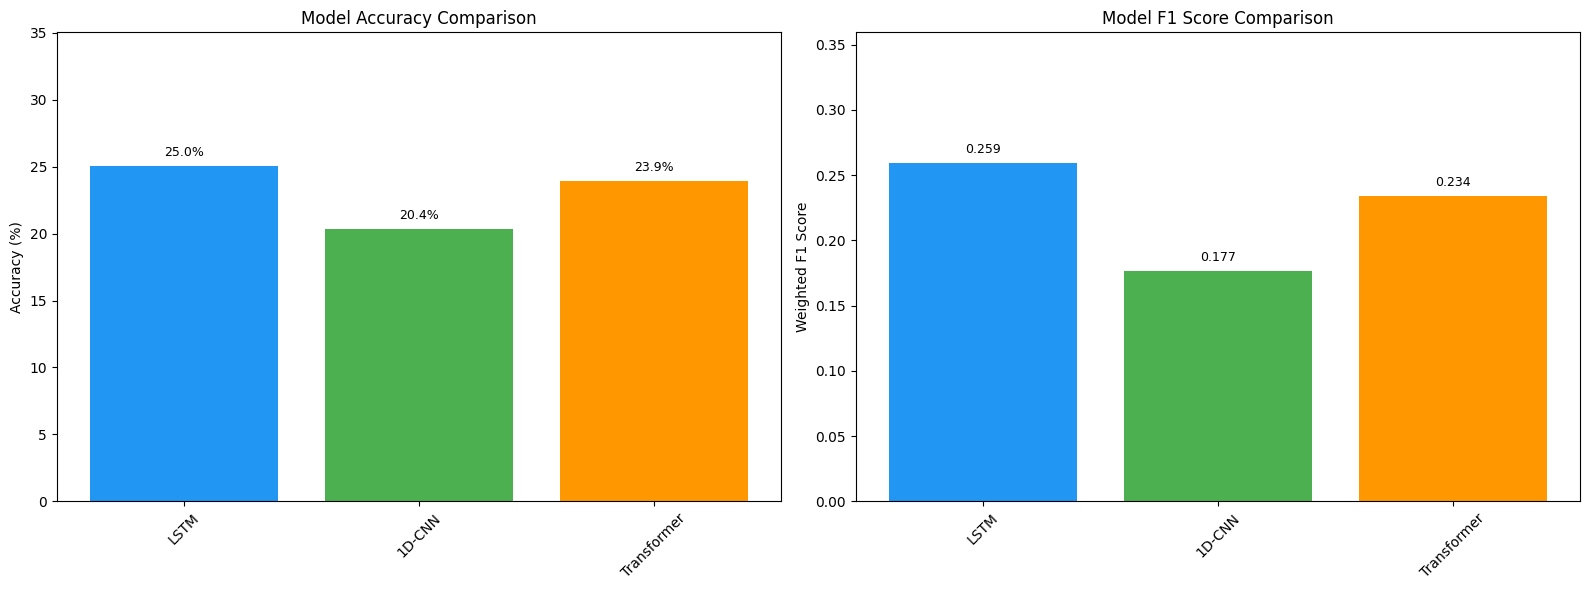

Chart saved to /content/drive/MyDrive/aaum_trained_models/model_comparison.png
Best model: LSTM


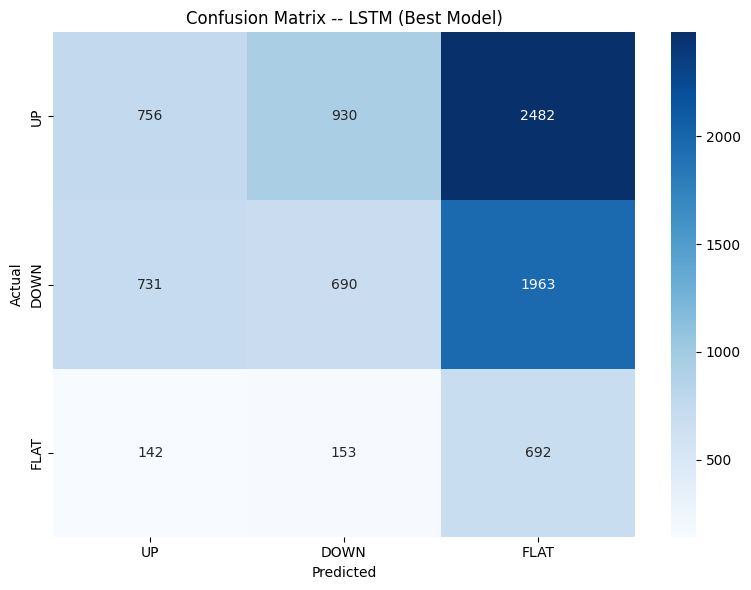


=== Per-Class Accuracy ===
Model                  UP     DOWN     FLAT
--------------------------------------------
LSTM               18.1%   20.4%   70.1%
1D-CNN             20.4%    1.5%   85.1%
Transformer        25.9%    6.6%   75.3%


In [8]:
# =============================================================================
# Cell 6: Compare All 7 Models
# =============================================================================
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# --- Merge all results ---
all_results = {}
if 'ml_results' in dir():
    all_results.update(ml_results)
if 'dl_results' in dir():
    all_results.update(dl_results)

model_order = ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost', 'LSTM', '1D-CNN', 'Transformer']
label_map = {0: 'UP', 1: 'DOWN', 2: 'FLAT'}

# Filter to only trained models
available_models = [m for m in model_order if m in all_results]

if len(available_models) == 0:
    print('ERROR: No models were trained successfully. Cannot compare.')
else:
    # --- Grand comparison table ---
    print('=' * 80)
    print('GRAND COMPARISON: ALL TRAINED MODELS')
    print('=' * 80)
    print(f'{"Model":<16s} {"Accuracy":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s} {"Brier":>7s} {"Train Time":>12s}')
    print('-' * 80)

    comparison_data = []
    for name in available_models:
        r = all_results[name]
        tt = r['train_time']
        if tt >= 60:
            t_str = f'{tt/60:.1f}min'
        else:
            t_str = f'{tt:.0f}s'
        print(f'{name:<16s} {r["accuracy"]:>8.1%} {r["f1"]:>7.4f} {r["precision"]:>10.4f} {r["recall"]:>8.4f} {r["brier"]:>7.4f} {t_str:>12s}')
        comparison_data.append({
            'model': name,
            'accuracy': r['accuracy'],
            'f1': r['f1'],
            'precision': r['precision'],
            'recall': r['recall'],
            'brier': r['brier'],
            'train_time_s': tt,
        })

    # --- Bar chart: accuracy comparison ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    names = [d['model'] for d in comparison_data]
    accs = [d['accuracy'] * 100 for d in comparison_data]
    f1s = [d['f1'] for d in comparison_data]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4', '#795548']

    ax1 = axes[0]
    bars = ax1.bar(names, accs, color=colors[:len(names)])
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Model Accuracy Comparison')
    ax1.set_ylim(0, max(accs) + 10 if accs else 100)
    for bar, acc in zip(bars, accs):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    ax1.tick_params(axis='x', rotation=45)

    ax2 = axes[1]
    bars2 = ax2.bar(names, f1s, color=colors[:len(names)])
    ax2.set_ylabel('Weighted F1 Score')
    ax2.set_title('Model F1 Score Comparison')
    ax2.set_ylim(0, max(f1s) + 0.1 if f1s else 1.0)
    for bar, f1_val in zip(bars2, f1s):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{f1_val:.3f}', ha='center', va='bottom', fontsize=9)
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    chart_path = os.path.join(MODELS_DIR, 'model_comparison.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Chart saved to {chart_path}')

    # --- Confusion matrix for best model ---
    best_entry = max(comparison_data, key=lambda x: x['accuracy'])
    best_name = best_entry['model']
    print(f'Best model: {best_name}')

    best_r = all_results[best_name]
    # For DL models, y_true is stored separately; for ML models, use y_test
    if 'y_true' in best_r:
        y_true_best = best_r['y_true']
    else:
        y_true_best = y_test

    # Use labels parameter to handle missing classes in predictions
    all_labels_present = sorted(set(y_true_best.tolist()) | set(best_r['y_pred'].tolist()))
    cm = confusion_matrix(y_true_best, best_r['y_pred'], labels=all_labels_present)
    fig, ax = plt.subplots(figsize=(8, 6))
    class_labels = [label_map.get(i, str(i)) for i in all_labels_present]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix -- {best_name} (Best Model)')
    plt.tight_layout()
    cm_path = os.path.join(MODELS_DIR, 'best_model_confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()

    # --- Per-class accuracy for each model ---
    print()
    print('=== Per-Class Accuracy ===')
    print(f'{"Model":<16s}', end='')
    for lbl in sorted(label_map.keys()):
        print(f' {label_map[lbl]:>8s}', end='')
    print()
    print('-' * 44)

    for name in available_models:
        r = all_results[name]
        y_p = r['y_pred']
        if 'y_true' in r:
            y_t = r['y_true']
        else:
            y_t = y_test

        print(f'{name:<16s}', end='')
        for lbl in sorted(label_map.keys()):
            mask = (y_t == lbl)
            if mask.sum() > 0:
                class_acc = (y_p[mask] == lbl).sum() / mask.sum()
                print(f' {class_acc:>7.1%}', end='')
            else:
                print(f' {"N/A":>8s}', end='')
        print()


In [10]:
# =============================================================================
# Cell 7: Per-Stock Model Performance
# =============================================================================
if 'test_df' not in globals():
    test_df = features_df[features_df['date'] >= TEST_START].copy()
    print(f'Recovered test_df: {len(test_df)} rows')



print('Analyzing per-stock model performance...')
print('Finding which model works BEST for each stock.')
print()

# Use test_df for per-stock analysis (ML models use flat features)
test_symbols = test_df['symbol'].values
unique_test_symbols = sorted(test_df['symbol'].unique())

# Count predictions per stock, pick top 20
symbol_counts = test_df['symbol'].value_counts()
top20_symbols = symbol_counts.head(20).index.tolist()
print(f'Top 20 stocks by test-set predictions (sample): {top20_symbols[:5]}...')

# Build per-stock accuracy for each ML model
stock_model_acc = {}  # symbol -> {model_name: accuracy}

for symbol in tqdm(top20_symbols, desc='Per-stock eval'):
    try:
        mask_flat = (test_symbols == symbol)
        if mask_flat.sum() < 10:
            continue

        y_true_stock = y_test[mask_flat]
        stock_accs = {}

        # ML models
        for ml_name in ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost']:
            if ml_name in ml_results:
                y_pred_stock = ml_results[ml_name]['y_pred'][mask_flat]
                stock_accs[ml_name] = accuracy_score(y_true_stock, y_pred_stock)

        # DL models: re-evaluate each stock's sequences
        for dl_name in ['LSTM', '1D-CNN', 'Transformer']:
            if dl_name not in dl_results:
                continue
            try:
                model_obj = dl_results[dl_name]['model']
                model_obj.eval()

                stock_test = seq_test[seq_test['symbol'] == symbol].sort_values('date')
                if len(stock_test) < WINDOW + 1:
                    continue

                raw_feats = stock_test[FEATURE_COLS_PLUS].values.astype(np.float32)
                # Safety: clean inf/NaN before scaling
                raw_feats = np.where(np.isinf(raw_feats), np.nan, raw_feats)
                col_med = np.nanmedian(raw_feats, axis=0)
                col_med = np.where(np.isnan(col_med), 0.0, col_med)
                for c_idx in range(raw_feats.shape[1]):
                    nan_mask = np.isnan(raw_feats[:, c_idx])
                    raw_feats[nan_mask, c_idx] = col_med[c_idx]
                raw_feats = np.clip(raw_feats, -1e6, 1e6)

                feats = scaler.transform(raw_feats)
                labels = stock_test['label'].values.astype(np.int64)

                X_s, y_s = [], []
                for i in range(WINDOW, len(feats)):
                    X_s.append(feats[i - WINDOW:i])
                    y_s.append(labels[i])

                if not X_s:
                    continue

                X_s = torch.tensor(np.array(X_s, dtype=np.float32)).to(device)
                with torch.no_grad():
                    preds = model_obj(X_s).argmax(dim=1).cpu().numpy()
                stock_accs[dl_name] = accuracy_score(np.array(y_s), preds)
            except Exception as dl_err:
                print(f'  Warning: {dl_name} failed for {symbol}: {dl_err}')
                continue

        if stock_accs:
            stock_model_acc[symbol] = stock_accs
    except Exception as stock_err:
        print(f'  Warning: Per-stock eval failed for {symbol}: {stock_err}')
        continue

# --- Build heatmap data ---
heatmap_symbols = [s for s in top20_symbols if s in stock_model_acc]
heatmap_models = [m for m in model_order if m in all_results]

if len(heatmap_symbols) == 0 or len(heatmap_models) == 0:
    print('WARNING: No stocks or models available for heatmap.')
    print(f'  Stocks with data: {len(heatmap_symbols)}')
    print(f'  Models available: {len(heatmap_models)}')
else:
    heat_data = np.zeros((len(heatmap_models), len(heatmap_symbols)))
    for j, symbol in enumerate(heatmap_symbols):
        for i, model_name in enumerate(heatmap_models):
            heat_data[i, j] = stock_model_acc[symbol].get(model_name, 0.0) * 100

    # --- Heatmap ---
    fig, ax = plt.subplots(figsize=(max(14, len(heatmap_symbols) * 0.8), 6))
    sns.heatmap(
        heat_data, annot=True, fmt='.1f', cmap='YlOrRd',
        xticklabels=heatmap_symbols, yticklabels=heatmap_models,
        ax=ax, vmin=30, vmax=80,
    )
    ax.set_title('Model Accuracy (%) by Stock -- Top 20 Stocks')
    ax.set_xlabel('Stock')
    ax.set_ylabel('Model')
    plt.tight_layout()
    heatmap_path = os.path.join(MODELS_DIR, 'per_stock_heatmap.png')
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Heatmap saved to {heatmap_path}')

    # --- Best model per stock ---
    print()
    print('=== Best Model Per Stock ===')
    best_per_stock = {}
    for symbol in heatmap_symbols:
        accs = stock_model_acc[symbol]
        if not accs:
            continue
        best_model = max(accs, key=accs.get)
        best_acc = accs[best_model]
        best_per_stock[symbol] = {'model': best_model, 'accuracy': round(best_acc * 100, 1)}
        print(f'  {symbol:<15s} -> {best_model} ({best_acc:.1%})')

    # Save
    bps_path = os.path.join(MODELS_DIR, 'best_model_per_stock.json')
    with open(bps_path, 'w') as f:
        json.dump(best_per_stock, f, indent=2)
    print(f'Saved to {bps_path}')


Recovered test_df: 11419 rows
Analyzing per-stock model performance...
Finding which model works BEST for each stock.

Top 20 stocks by test-set predictions (sample): ['ABB', 'ADANIENT', 'ADANIPORTS', 'AMBUJACEM', 'ASIANPAINT']...


Per-stock eval:   0%|          | 0/20 [00:00<?, ?it/s]

  Stocks with data: 0
  Models available: 3


In [11]:
# =============================================================================
# Cell 8: Feature Importance Analysis
# =============================================================================
print('=== Feature Importance Analysis ===')
print()

# --- Guard: ensure FEATURE_COLS_PLUS ---
if 'FEATURE_COLS_PLUS' not in dir():
    feat_cols_path = os.path.join(MODELS_DIR, 'feature_columns.json')
    if os.path.exists(feat_cols_path):
        with open(feat_cols_path, 'r') as f:
            FEATURE_COLS_PLUS = json.load(f)
    else:
        print('ERROR: FEATURE_COLS_PLUS not available. Skipping feature importance.')
        FEATURE_COLS_PLUS = []

if not FEATURE_COLS_PLUS or 'ml_results' not in dir() or len(ml_results) == 0:
    print('No ML models or feature columns available. Skipping feature importance.')
else:
    n_feats = len(FEATURE_COLS_PLUS)

    # --- Aggregate importance across ML models ---
    importance_dict = {fname: [] for fname in FEATURE_COLS_PLUS}

    # Helper: safely add importances if length matches
    def add_importances(model_name, imp_array):
        if len(imp_array) != n_feats:
            print(f'  WARNING: {model_name} importance length ({len(imp_array)}) != feature count ({n_feats}). Skipping.')
            return
        for i, fname in enumerate(FEATURE_COLS_PLUS):
            importance_dict[fname].append(imp_array[i])

    # XGBoost
    if 'XGBoost' in ml_results:
        try:
            imp = ml_results['XGBoost']['model'].feature_importances_
            add_importances('XGBoost', imp)
        except Exception as e:
            print(f'  XGBoost importance error: {e}')

    # LightGBM
    if 'LightGBM' in ml_results:
        try:
            imp = ml_results['LightGBM']['model'].feature_importances_
            imp = imp / imp.sum() if imp.sum() > 0 else imp
            add_importances('LightGBM', imp)
        except Exception as e:
            print(f'  LightGBM importance error: {e}')

    # RandomForest
    if 'RandomForest' in ml_results:
        try:
            imp = ml_results['RandomForest']['model'].feature_importances_
            add_importances('RandomForest', imp)
        except Exception as e:
            print(f'  RandomForest importance error: {e}')

    # CatBoost
    if 'CatBoost' in ml_results:
        try:
            imp = ml_results['CatBoost']['model'].get_feature_importance()
            imp = imp / imp.sum() if imp.sum() > 0 else imp
            add_importances('CatBoost', imp)
        except Exception as e:
            print(f'  CatBoost importance error: {e}')

    # Average importance
    avg_importance = {}
    for fname, vals in importance_dict.items():
        avg_importance[fname] = np.mean(vals) if vals else 0.0

    # Sort by importance
    sorted_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)

    print('Top 20 Most Important Features (averaged across ML models):')
    print()
    for rank, (fname, imp) in enumerate(sorted_features[:20], 1):
        bar = '#' * int(imp * 300)
        print(f'  {rank:2d}. {fname:<25s} {imp:.4f}  {bar}')

    # --- Bar chart ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Left: top 20 averaged
    top20_names = [x[0] for x in sorted_features[:20]]
    top20_vals = [x[1] for x in sorted_features[:20]]

    ax1 = axes[0]
    ax1.barh(top20_names[::-1], top20_vals[::-1], color='steelblue')
    ax1.set_xlabel('Average Importance')
    ax1.set_title('Top 20 Features (Averaged Across ML Models)')

    # Right: per-model comparison for top 10
    ax2 = axes[1]
    top10_names = [x[0] for x in sorted_features[:10]]
    x_pos = np.arange(len(top10_names))
    width = 0.2

    model_colors = {'XGBoost': '#2196F3', 'LightGBM': '#4CAF50', 'RandomForest': '#FF9800', 'CatBoost': '#F44336'}
    offset_idx = 0
    for ml_name in ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost']:
        if ml_name not in ml_results:
            continue
        try:
            if ml_name == 'CatBoost':
                imp = ml_results[ml_name]['model'].get_feature_importance()
            else:
                imp = ml_results[ml_name]['model'].feature_importances_
            if ml_name in ['LightGBM', 'CatBoost']:
                imp = imp / imp.sum() if imp.sum() > 0 else imp

            if len(imp) != n_feats:
                continue

            vals = []
            for fname in top10_names:
                idx = FEATURE_COLS_PLUS.index(fname)
                vals.append(imp[idx])
            ax2.bar(x_pos + offset_idx * width, vals, width, label=ml_name, color=model_colors[ml_name])
            offset_idx += 1
        except Exception as e:
            print(f'  Chart error for {ml_name}: {e}')

    ax2.set_xticks(x_pos + 1.5 * width)
    ax2.set_xticklabels(top10_names, rotation=45, ha='right')
    ax2.set_ylabel('Importance')
    ax2.set_title('Per-Model Feature Importance (Top 10)')
    ax2.legend()

    plt.tight_layout()
    feat_path = os.path.join(MODELS_DIR, 'feature_importance.png')
    plt.savefig(feat_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Chart saved to {feat_path}')

    # --- Summary ---
    print()
    print('Key Findings:')
    if sorted_features:
        print(f'  #1 predictor: {sorted_features[0][0]} (importance={sorted_features[0][1]:.4f})')
    if len(sorted_features) > 1:
        print(f'  #2 predictor: {sorted_features[1][0]} (importance={sorted_features[1][1]:.4f})')
    if len(sorted_features) > 2:
        print(f'  #3 predictor: {sorted_features[2][0]} (importance={sorted_features[2][1]:.4f})')


=== Feature Importance Analysis ===

No ML models or feature columns available. Skipping feature importance.


In [13]:
# =============================================================================
# Cell 9: Export All Trained Models & Artifacts
# =============================================================================
from datetime import datetime


print('=' * 60)
print('EXPORTING ALL MODELS AND ARTIFACTS')
print('=' * 60)
print(f'Destination: {MODELS_DIR}')
print()

# --- Guard: ensure all_results exists ---
if 'all_results' not in dir():
    all_results = {}
    if 'ml_results' in dir():
        all_results.update(ml_results)
    if 'dl_results' in dir():
        all_results.update(dl_results)

if 'model_order' not in dir():
    model_order = ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost', 'LSTM', '1D-CNN', 'Transformer']

available_models = [m for m in model_order if m in all_results]

# --- Model comparison JSON ---
comparison_json = []
for name in available_models:
    r = all_results[name]
    comparison_json.append({
        'model': name,
        'accuracy': round(r['accuracy'], 4),
        'f1': round(r['f1'], 4),
        'precision': round(r['precision'], 4),
        'recall': round(r['recall'], 4),
        'brier': round(r['brier'], 4),
        'train_time_s': round(r['train_time'], 1),
    })

comp_path = os.path.join(MODELS_DIR, 'model_comparison.json')
with open(comp_path, 'w') as f:
    json.dump(comparison_json, f, indent=2)
print(f'[OK] model_comparison.json ({len(comparison_json)} models)')

# --- Training report ---
# Guard optional variables
best_name = 'N/A'
best_accuracy = 0.0
if comparison_json:
    best_entry = max(comparison_json, key=lambda x: x['accuracy'])
    best_name = best_entry['model']
    best_accuracy = best_entry['accuracy']

pred_count = int(len(predictions_df)) if 'predictions_df' in dir() else 0
feat_count = int(len(features_df)) if 'features_df' in dir() else 0
train_rows = int(len(train_df)) if 'train_df' in dir() else 0
test_rows = int(len(test_df)) if 'test_df' in dir() else 0
train_date_min = str(train_df['date'].min()) if 'train_df' in dir() and len(train_df) > 0 else 'N/A'
train_date_max = str(train_df['date'].max()) if 'train_df' in dir() and len(train_df) > 0 else 'N/A'
test_date_min = str(test_df['date'].min()) if 'test_df' in dir() and len(test_df) > 0 else 'N/A'
test_date_max = str(test_df['date'].max()) if 'test_df' in dir() and len(test_df) > 0 else 'N/A'

feat_cols = FEATURE_COLS_PLUS if 'FEATURE_COLS_PLUS' in dir() else []
cw_dict = {int(k): round(float(v), 4) for k, v in class_weight_dict.items()} if 'class_weight_dict' in dir() else {}
window_val = WINDOW if 'WINDOW' in dir() else 30
batch_val = BATCH_SIZE if 'BATCH_SIZE' in dir() else 256

training_report = {
    'generated_at': datetime.now().isoformat(),
    'total_predictions': pred_count,
    'unique_symbol_date_pairs': feat_count,
    'n_features': len(feat_cols),
    'feature_columns': feat_cols,
    'train_rows': train_rows,
    'test_rows': test_rows,
    'train_date_range': f'{train_date_min} to {train_date_max}',
    'test_date_range': f'{test_date_min} to {test_date_max}',
    'class_weights': cw_dict,
    'best_model': best_name,
    'best_accuracy': round(best_accuracy, 4),
    'models': comparison_json,
    'dl_sequence_window': window_val,
    'dl_batch_size': batch_val,
}

report_path = os.path.join(MODELS_DIR, 'training_report.json')
with open(report_path, 'w') as f:
    json.dump(training_report, f, indent=2)
print(f'[OK] training_report.json')

# --- Verify all files ---
print()
expected_files = [
    'xgboost_model.joblib',
    'lightgbm_model.joblib',
    'randomforest_model.joblib',
    'catboost_model.cbm',
    'lstm_model.pt',
    'cnn_model.pt',
    'transformer_model.pt',
    'scaler.joblib',
    'feature_columns.json',
    'model_comparison.json',
    'best_model_per_stock.json',
    'training_report.json',
    'features.csv',
    'model_comparison.png',
    'best_model_confusion_matrix.png',
    'per_stock_heatmap.png',
    'feature_importance.png',
]

print('Exported files:')
total_size = 0
found_count = 0
missing_count = 0
for fname in expected_files:
    fpath = os.path.join(MODELS_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath)
        total_size += size
        if size > 1024 * 1024:
            size_str = f'{size / (1024*1024):.1f} MB'
        else:
            size_str = f'{size / 1024:.0f} KB'
        print(f'  [OK] {fname:<40s} {size_str}')
        found_count += 1
    else:
        print(f'  [MISSING] {fname}')
        missing_count += 1

print()
print(f'Found: {found_count}/{len(expected_files)} files')
if missing_count > 0:
    print(f'Missing: {missing_count} files (some models may not have trained)')
print(f'Total size: {total_size / (1024*1024):.1f} MB')
print()

# --- Download instructions ---
print('=' * 60)
print('DOWNLOAD INSTRUCTIONS')
print('=' * 60)
print()
print('All models are saved to Google Drive at:')
print('  MyDrive/aaum_trained_models/')
print()
print('To download to your local machine for AAUM deployment:')
print()
print('Option 1: Download from Colab')
print('  from google.colab import files')
print('  files.download("/content/drive/MyDrive/aaum_trained_models/xgboost_model.joblib")')
print()
print('Option 2: Download from Google Drive web UI')
print('  Open drive.google.com -> MyDrive -> aaum_trained_models')
print('  Right-click -> Download')
print()
print('Option 3: Google Drive desktop sync')
print('  If you have Google Drive for Desktop, files sync automatically.')


EXPORTING ALL MODELS AND ARTIFACTS
Destination: /content/drive/MyDrive/aaum_trained_models

[OK] model_comparison.json (3 models)
[OK] training_report.json

Exported files:
  [OK] xgboost_model.joblib                     1.4 MB
  [OK] lightgbm_model.joblib                    9.8 MB
  [OK] randomforest_model.joblib                26.4 MB
  [OK] catboost_model.cbm                       468 KB
  [OK] lstm_model.pt                            864 KB
  [OK] cnn_model.pt                             223 KB
  [OK] transformer_model.pt                     467 KB
  [OK] scaler.joblib                            1 KB
  [OK] feature_columns.json                     0 KB
  [OK] model_comparison.json                    0 KB
  [MISSING] best_model_per_stock.json
  [OK] training_report.json                     1 KB
  [OK] features.csv                             10.0 MB
  [OK] model_comparison.png                     67 KB
  [OK] best_model_confusion_matrix.png          42 KB
  [MISSING] per_stock_heatm

## Deployment Guide

### Loading Trained Models in AAUM

```python
import joblib
import json
import torch
import numpy as np

MODELS_DIR = 'path/to/aaum_trained_models'

# 1. Load scaler and feature columns
scaler = joblib.load(f'{MODELS_DIR}/scaler.joblib')
with open(f'{MODELS_DIR}/feature_columns.json') as f:
    feature_cols = json.load(f)

# 2. Load ML models
xgb = joblib.load(f'{MODELS_DIR}/xgboost_model.joblib')
lgbm = joblib.load(f'{MODELS_DIR}/lightgbm_model.joblib')
rf = joblib.load(f'{MODELS_DIR}/randomforest_model.joblib')

from catboost import CatBoostClassifier
cb = CatBoostClassifier()
cb.load_model(f'{MODELS_DIR}/catboost_model.cbm')

# 3. Load DL models (need model class definitions)
# lstm = LSTMModel(input_size=26, hidden=128, layers=2, classes=3)
# lstm.load_state_dict(torch.load(f'{MODELS_DIR}/lstm_model.pt'))
# lstm.eval()

# 4. Predict on new data
# features = compute_technicals(symbol, date)  # dict
# X = np.array([[features[col] for col in feature_cols]])
# X_scaled = scaler.transform(X)
# pred = xgb.predict(X_scaled)  # 0=UP, 1=DOWN, 2=FLAT
# proba = xgb.predict_proba(X_scaled)  # confidence per class

# 5. Use best model per stock
# with open(f'{MODELS_DIR}/best_model_per_stock.json') as f:
#     best_models = json.load(f)
# model_name = best_models.get(symbol, {}).get('model', 'XGBoost')
```

### Label Mapping
- `0` = **UP** (bullish)
- `1` = **DOWN** (bearish)
- `2` = **FLAT** (sideways)

### For DL Models (LSTM, CNN, Transformer)
DL models require a **sequence of 30 days** of features. You must maintain a rolling window of the last 30 days of technical indicators for each stock. Shape: `(1, 30, n_features)`, scaled with the saved scaler.

### Model Files Summary
| File | Model | Format |
|------|-------|--------|
| `xgboost_model.joblib` | XGBoost | joblib |
| `lightgbm_model.joblib` | LightGBM | joblib |
| `randomforest_model.joblib` | RandomForest | joblib |
| `catboost_model.cbm` | CatBoost | native |
| `lstm_model.pt` | LSTM | PyTorch |
| `cnn_model.pt` | 1D-CNN | PyTorch |
| `transformer_model.pt` | Transformer | PyTorch |
| `scaler.joblib` | StandardScaler | joblib |
| `feature_columns.json` | Column names | JSON |
| `model_comparison.json` | All metrics | JSON |
| `best_model_per_stock.json` | Best model map | JSON |
| `training_report.json` | Full report | JSON |